# Notebook 04 — Churn Analysis and Drivers

This notebook answers the business question: among engaged players, what separates
those who go dormant from those who stay, and where could a studio step in?

Churn is concentrated in the low and mid tiers, so the driver work focuses there. The
model is framed as **driver ranking**, not a deployed predictor. With 67 churned
players the goal is to rank what matters and read the direction, not to forecast.

In [1]:
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import make_pipeline

DATA = Path("..")/"data"
NAVY, GOLD, RED = "#1A3A5C", "#C9A14A", "#C62828"
features = pd.read_csv(DATA/"player_features.csv")
print(f"{len(features)} engaged players, {int(features.churned.sum())} churned "
      f"({100*features.churned.mean():.1f}%)")

704 engaged players, 67 churned (9.5%)


## 1. Where churn lives

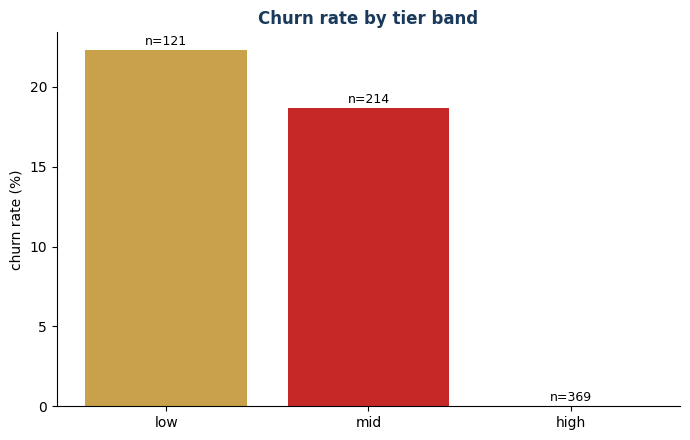

,players,churned,rate
tier_band,,,
low,121,27,22.3
mid,214,40,18.7
high,369,0,0.0


In [2]:
band = features.groupby("tier_band").agg(players=("churned","size"), churned=("churned","sum"))
band["rate"] = (100*band.churned/band.players).round(1)
band = band.reindex(["low","mid","high"])
fig, ax = plt.subplots(figsize=(7,4.5))
b = ax.bar(band.index, band.rate, color=[GOLD, RED, NAVY])
for bar, n in zip(b, band.players):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f"n={int(n)}", ha="center", fontsize=9)
ax.set_ylabel("churn rate (%)"); ax.set_title("Churn rate by tier band", color=NAVY, fontweight="bold")
ax.spines[["top","right"]].set_visible(False); plt.tight_layout(); plt.show()
band

High tier engaged players essentially never churn, likely because rank decay forces
them to keep playing and commitment is high. Churn sits in the low and mid tiers, so
the rest of the analysis focuses there.

In [3]:
sub = features[features.tier_band.isin(["low","mid"])].copy()
print(f"low + mid: {len(sub)} players, {int(sub.churned.sum())} churned ({100*sub.churned.mean():.0f}%)")

low + mid: 335 players, 67 churned (20%)


## 2. The leading indicator: days since last game

Before any behavioral driver, the clearest signal is simply how recently the player
last played. Churners had already tapered off weeks before the window closed. It sits
right next to the outcome in time, so we report it as the leading early warning metric
and keep it out of the behavioral model below.

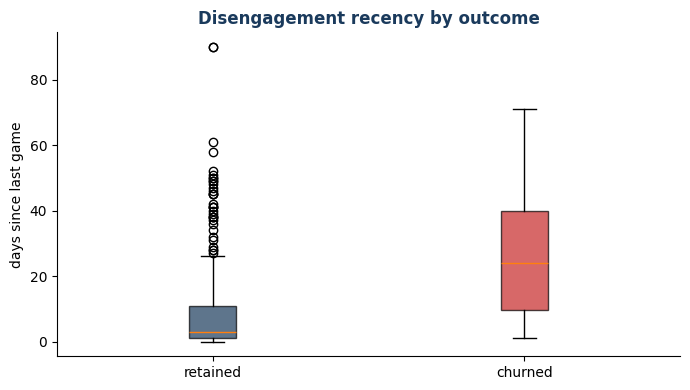

median days since last game  retained: 3  churned: 24


In [4]:
fig, ax = plt.subplots(figsize=(7,4))
data = [sub[sub.churned==0].days_since_last, sub[sub.churned==1].days_since_last]
bp = ax.boxplot(data, patch_artist=True); ax.set_xticks([1,2]); ax.set_xticklabels(["retained","churned"])
for patch, col in zip(bp["boxes"], [NAVY, RED]): patch.set_facecolor(col); patch.set_alpha(.7)
ax.set_ylabel("days since last game"); ax.set_title("Disengagement recency by outcome", color=NAVY, fontweight="bold")
ax.spines[["top","right"]].set_visible(False); plt.tight_layout(); plt.show()
print("median days since last game  retained: %d  churned: %d" % (
    sub[sub.churned==0].days_since_last.median(), sub[sub.churned==1].days_since_last.median()))

## 3. Behavioral drivers

A class weighted logistic regression and a random forest, cross validated, ranking the
behavioral features. `days_since_last` is excluded so the model captures behavior
**before** the obvious tapering, the signals a studio could act on early.

In [5]:
feats = ["games_trend","games_per_active_day","win_rate","win_rate_trend","avg_kda",
         "avg_duration_min","unique_champions","role_focus","night_share","account_level",
         "time_dead_share","surrender_loss_share"]
sub[feats] = sub[feats].fillna(sub[feats].median())
X, y = sub[feats], sub.churned
cv = StratifiedKFold(5, shuffle=True, random_state=42)
logit = make_pipeline(StandardScaler(), LogisticRegression(class_weight="balanced", max_iter=2000))
rf = RandomForestClassifier(n_estimators=400, class_weight="balanced", random_state=42, min_samples_leaf=5)
auc_l = cross_val_score(logit, X, y, cv=cv, scoring="roc_auc")
auc_r = cross_val_score(rf, X, y, cv=cv, scoring="roc_auc")
print("Cross validated ROC AUC")
print("  logistic      : %.3f (+/- %.3f)" % (auc_l.mean(), auc_l.std()))
print("  random forest : %.3f (+/- %.3f)" % (auc_r.mean(), auc_r.std()))

Cross validated ROC AUC
  logistic      : 0.717 (+/- 0.068)
  random forest : 0.692 (+/- 0.061)


In [6]:
logit.fit(X, y); rf.fit(X, y)
drivers = pd.DataFrame({
    "logit_coef": pd.Series(logit.named_steps["logisticregression"].coef_[0], index=feats),
    "rf_importance": pd.Series(rf.feature_importances_, index=feats),
}).reindex(pd.Series(rf.feature_importances_, index=feats).sort_values(ascending=False).index)
drivers.round(3)

,logit_coef,rf_importance
games_per_active_day,0.642,0.112
games_trend,-0.586,0.104
avg_kda,0.419,0.103
time_dead_share,-0.055,0.093
role_focus,0.118,0.086
win_rate,-0.119,0.082
avg_duration_min,-0.080,0.082
night_share,0.297,0.081
unique_champions,-0.499,0.076
account_level,-0.248,0.065


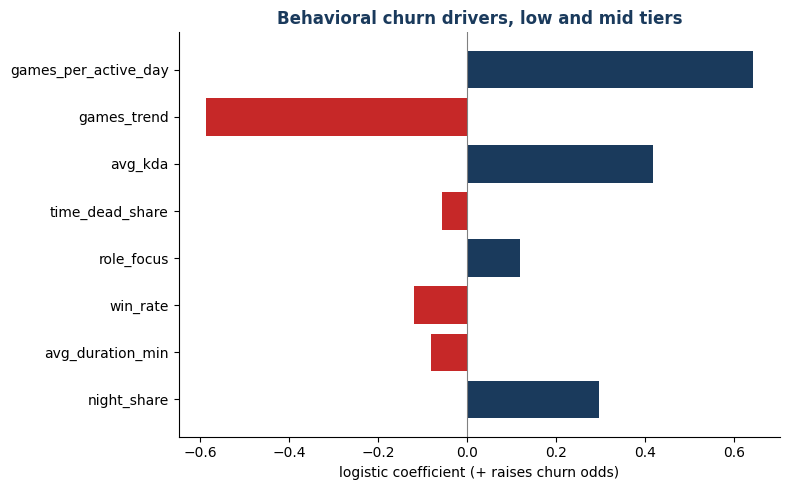

In [7]:
top = drivers.head(8).iloc[::-1]
colors = [RED if v < 0 else NAVY for v in top.logit_coef]
fig, ax = plt.subplots(figsize=(8,5))
ax.barh(top.index, top.logit_coef, color=colors); ax.axvline(0, color="grey", lw=.8)
ax.set_xlabel("logistic coefficient (+ raises churn odds)")
ax.set_title("Behavioral churn drivers, low and mid tiers", color=NAVY, fontweight="bold")
ax.spines[["top","right"]].set_visible(False); plt.tight_layout(); plt.show()

## 4. Churn by role

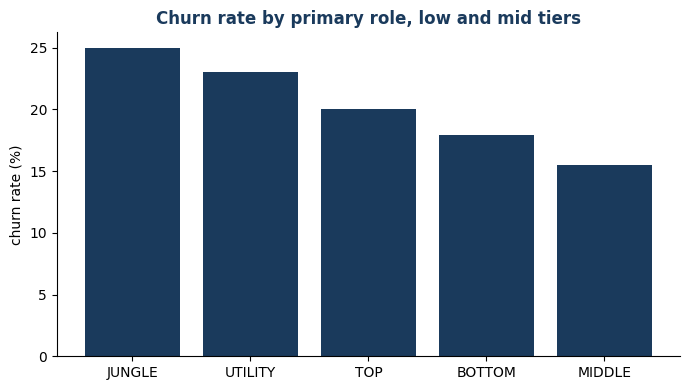

,players,churned,rate
primary_role,,,
JUNGLE,48,12,25.0
UTILITY,74,17,23.0
TOP,75,15,20.0
BOTTOM,67,12,17.9
MIDDLE,71,11,15.5


In [8]:
role = sub.groupby("primary_role").agg(players=("churned","size"), churned=("churned","sum"))
role["rate"] = (100*role.churned/role.players).round(1)
role = role.sort_values("rate", ascending=False)
fig, ax = plt.subplots(figsize=(7,4))
ax.bar(role.index, role.rate, color=NAVY)
ax.set_ylabel("churn rate (%)"); ax.set_title("Churn rate by primary role, low and mid tiers", color=NAVY, fontweight="bold")
ax.spines[["top","right"]].set_visible(False); plt.tight_layout(); plt.show()
role

## 5. The business read

**Churn is disengagement, not frustration.** Churners are competent, their win rate is
fine and their KDA is actually higher. They are narrow and bursty, leaning on few
champions and one role, cramming games into concentrated sessions without growing their
weekly volume. The frustration hypotheses did not hold, churners spend less time dead
and are less often the team's scapegoat.

**Early warning signals**, in order of strength:
- Days since the last game rising. The single clearest sign, and it shows up weeks
  before a player formally goes dormant.
- Engagement that stays flat instead of growing.
- A narrowing champion pool and a single role focus.
- A newer account, less invested over time.
- A modest extra share of quick, one sided losses.

**Where a studio could step in.** Watch engaged players whose weekly games stop growing
and whose last session is slipping back. That is the window to re engage, through
match quality, fresh content, champion recommendations to widen a narrow pool, and
extra support for newer accounts. Jungle and support players churn most, so role
specific quality of life matters there.

This closes the analysis. The same findings feed the Tableau dashboard and the project
README.